# DL073 优化收敛与隐式偏置

发行073映射原大纲T1。本Notebook从空内核实际重做完整实验。先预测结果，再逐单元执行；所有数据原创、CPU离线。图由固定outputs绘制，下面先核对重跑数组再展示。

In [1]:
from pathlib import Path  # 当前目录应为本单元。
import json, numpy as np  # 结果读取与数值核验。
from IPython.display import display, Image  # 内嵌PNG到Notebook。
print('working directory:', Path.cwd().name)  # 只显示目录名，避免机器路径。

working directory: 073


## 1 先做手算可核验的机制
数组形状与定义见data/README.md。不要把程序输出当作理解推导的替代。

In [2]:
from generate_data import generate  # 原创可分数据与二次曲率。
from experiment import logistic, descent_quadratic  # 同源码的可核验数学函数。
d = generate()  # 无下载，确定性生成。
loss, grad = logistic(np.zeros(2), d['x'], d['y'])  # 零点应给log2和[-.55,-.6]。
print('zero loss, gradient:', loss, grad)  # 不手工写假输出。
np.testing.assert_allclose(grad, [-.55, -.6], atol=1e-14)  # 手算独立锚点。

zero loss, gradient: 0.6931471805599453 [-0.55 -0.6 ]


In [3]:
points, values = descent_quadratic(d['q'], d['w0'], .25, 50)  # 真正更新50次。
bound = 40 / np.arange(1, 51)  # t=0无界，排除。
print('maximum observed minus bound:', np.max(values[1:]-bound))  # 应非正。
np.testing.assert_array_less(values[1:], bound + 1e-12)  # 容忍浮点误差。

maximum observed minus bound: -0.7999999999974343


## 2 完整实验重跑
调用run确实重新计算全部预定配置；输出另存notebook_outputs。运行时间只反映当前CPU，不构成跨机器性能比较。

In [4]:
from experiment import run  # 与命令行相同完整入口。
result = run('notebook_outputs')  # 真实重新抽样或训练，不复用固定输出。
print('unit:', result['unit'], 'runtime:', result['runtime'])  # 保存真实版本与时间。

unit: 073 runtime: {'python': '3.12.14', 'numpy': '2.3.5', 'seconds': 1.6555049190001228, 'device': 'CPU', 'dtype': 'float64'}


In [5]:
for row in result['logistic']['runs']:  # 保留全部初始化，不选最佳。
    print(row['initial'], 'angle:', row['angle_at_10'], '->', row['final_angle_deg'])
print('L, eta:', result['logistic']['L'], result['logistic']['eta'])  # 实际曲率尺度。

[0.0, 0.0] angle: 16.246193154013167 -> 3.618897351419806
[3.0, -2.0] angle: 10.929014835738107 -> 3.5939629189684883
[-2.0, 3.0] angle: 54.884405092904494 -> 3.8309528010128164
L, eta: 0.7594233208908726 1.3167886374978701


## 3 逐数组核对固定发行结果
同环境重跑应相同；跨BLAS或平台可能有舍入差，使用小容差。NaN仅在有明确定义的未定义量处按相同位置匹配。

In [6]:
reference = np.load('outputs/trajectories.npz', allow_pickle=False)  # 固定发行证据。
replayed = np.load('notebook_outputs/trajectories.npz', allow_pickle=False)  # 刚重跑结果。
if set(reference.files) != set(replayed.files):  # 不依赖可被-O删掉的assert。
    raise ValueError('array keys differ')
for name in reference.files:  # 每个数组都检查，不只检查摘要。
    np.testing.assert_allclose(replayed[name], reference[name], rtol=1e-10, atol=1e-11, equal_nan=True)
print('checked arrays:', len(reference.files))  # 实际核验数量。

checked arrays: 15


## 4 读图并写出限制
图是make_figures.py由固定outputs产生；上一单元已核对刚重跑的全部数组。改变实验后应重新画图，不能继续把旧图当新结果。

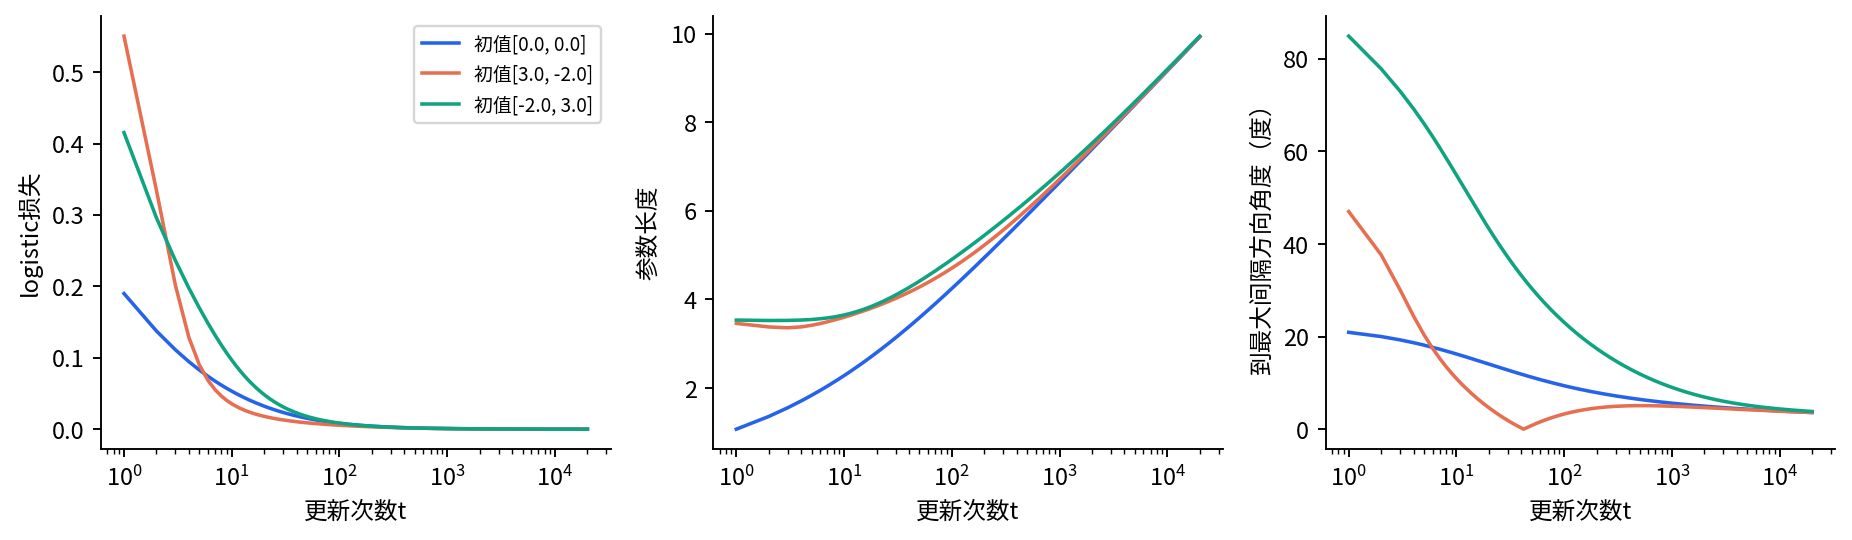

In [7]:
display(Image(filename='figures/04_directions.png'))  # 内嵌真实结果图。

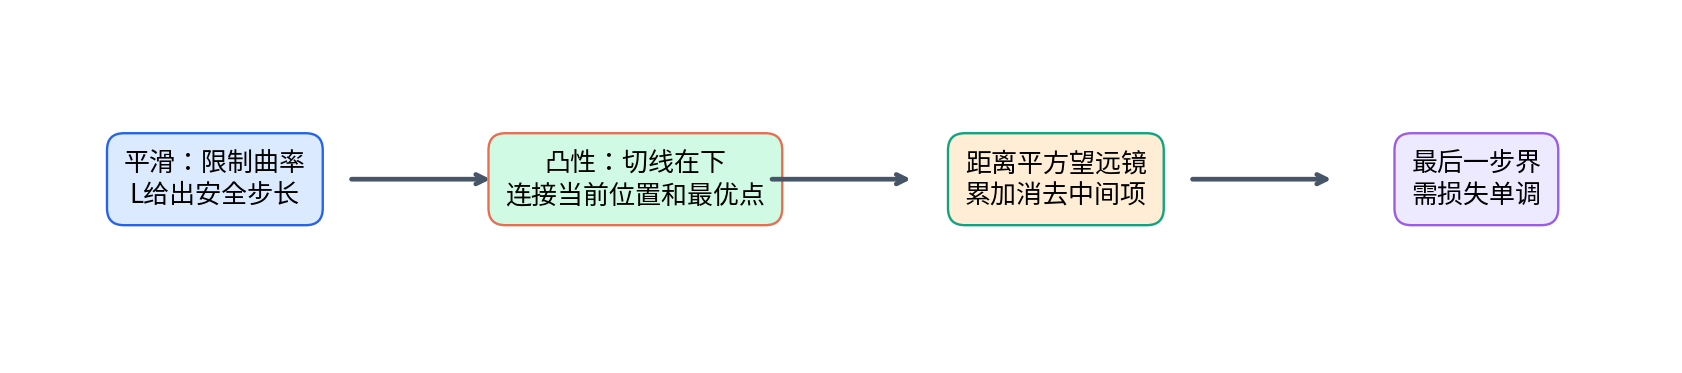

In [8]:
display(Image(filename='figures/01_proof.png'))  # 机制图不是额外实验结果。

## 5 自检
回到lab完成故障注入与扩展设计。明确已执行和仅提出的实验，解释至少一条不能外推的条件。答案在answers.md，不使用测试结果挑选最好配置。